In [1]:
!pip install h5py

In [2]:
import os
import pandas as pd
import time
import numpy as np
pd.set_option('display.max_columns', None) # so we can see all columns in a wide DataFrame

from sklearn.linear_model import RidgeClassifier
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

import h5py
import joblib

import shap

import warnings
warnings.filterwarnings('ignore')

## MACHINE LEARNING

## 1. Modelling Boxscore Stats

In [3]:
# Loading the combined_stats.csv file
engineered_Data = pd.read_csv(r"C:\Users\User\Dropbox\RU45-Sussex OneDrive\NBA Games Prediction Model\data\feature_engineered_csv\engDF_final_new.csv", index_col=0)
engineered_Data

,date,season,mp,team_x,total,team_opp,total_opp,won,home,home_opp,target,avg_points_scored,avg_points_allowed,shooting_percentage,three_point_percentage,free_throw_percentage,offensive_rebound_rate,defensive_rebound_rate,point_differential,cumulative_point_differential,PER_Combined,PER_Combined_opp,win_percent,win_streak,losing_streak,elo_rating,elo_rating_opp,head_to_head_win_ratio,average_points_scored,average_points_allowed,rest_days,cumulative_wins,cumulative_games_played,avg_points_scored_4_x,avg_points_allowed_4_x,shooting_percentage_4_x,three_point_percentage_4_x,free_throw_percentage_4_x,offensive_rebound_rate_4_x,defensive_rebound_rate_4_x,point_differential_4_x,cumulative_point_differential_4_x,PER_Combined_4_x,PER_Combined_opp_4_x,win_percent_4_x,win_streak_4_x,losing_streak_4_x,elo_rating_4_x,elo_rating_opp_4_x,head_to_head_win_ratio_4_x,average_points_scored_4_x,average_points_allowed_4_x,rest_days_4_x,cumulative_wins_4_x,cumulative_games_played_4_x,season_4_x,home_next,team_opp_next_x,date_next,PER_Combined_opp_next,elo_rating_opp_next,head_to_head_win_ratio_next,avg_points_scored_4_y,avg_points_allowed_4_y,shooting_percentage_4_y,three_point_percentage_4_y,free_throw_percentage_4_y,offensive_rebound_rate_4_y,defensive_rebound_rate_4_y,point_differential_4_y,cumulative_point_differential_4_y,PER_Combined_4_y,PER_Combined_opp_4_y,win_percent_4_y,win_streak_4_y,losing_streak_4_y,elo_rating_4_y,elo_rating_opp_4_y,head_to_head_win_ratio_4_y,average_points_scored_4_y,average_points_allowed_4_y,rest_days_4_y,cumulative_wins_4_y,cumulative_games_played_4_y,season_4_y,team_opp_next_y,team_y
0,07/11/2013,2014,240,ATL,107,DEN,109,False,0,1,1,104.75,104.5,0.469136,0.384615,0.677966,0.196203,0.803797,-2,-1,86.300000,68.300000,40.000000,0,1,1501.406424,1500.000000,0.250,102.000000,100.50,1,2,5,105.979167,108.750,0.474531,0.373058,0.706140,0.174869,0.825131,2.00,-1.50,86.300000,66.400000,43.333333,0.50,0.50,1492.711282,1500.000000,0.312500,105.562500,102.125000,1.00,1.50,3.5,2014,1,ORL,09/11/2013,62.300000,1500.000000,0.250000,103.287500,101.420833,0.457471,0.426339,0.678029,0.243594,0.756406,11.75,24.25,62.300,82.575000,48.333333,1.50,0.25,1493.461336,1484.439709,0.218750,96.125000,97.187500,1.25,2.25,4.5,2014,ATL,ORL
1,09/11/2013,2014,240,ATL,104,ORL,94,True,1,0,1,105.20,105.4,0.466507,0.367521,0.678832,0.215686,0.784314,10,9,86.300000,62.300000,50.000000,1,0,1485.341656,1500.000000,0.250,102.500000,105.25,1,3,6,105.029167,105.600,0.469447,0.381605,0.682991,0.190911,0.809089,2.75,1.25,86.300000,61.475000,43.333333,0.50,0.50,1493.046697,1500.000000,0.312500,106.875000,102.937500,1.00,2.00,4.5,2014,0,CHA,11/11/2013,77.400000,1500.000000,0.375000,88.029167,93.725000,0.404962,0.274453,0.642326,0.265804,0.734196,-6.00,-25.75,51.950,69.725000,48.333333,0.75,0.50,1497.009463,1443.153083,0.312500,96.041667,100.541667,0.75,2.25,4.5,2014,ATL,CHA
2,11/11/2013,2014,240,ATL,103,CHA,94,True,0,1,0,104.20,100.6,0.465278,0.366071,0.655462,0.219048,0.780952,9,18,86.300000,77.400000,57.142857,2,0,1502.016298,1500.000000,0.375,102.750000,97.00,1,4,7,104.704167,104.125,0.466485,0.377378,0.668826,0.202816,0.797184,5.50,6.75,86.300000,65.575000,49.285714,1.00,0.25,1493.366694,1500.000000,0.343750,105.437500,101.562500,1.00,2.75,5.5,2014,1,NYK,13/11/2013,65.700000,1500.000000,0.250000,90.408333,90.308333,0.433707,0.315244,0.808751,0.269915,0.730085,-8.75,-9.50,63.475,74.925000,32.916667,0.25,1.50,1480.756401,1481.559748,0.250000,104.125000,104.125000,1.50,1.50,4.5,2014,ATL,NYK
3,13/11/2013,2014,240,ATL,91,NYK,95,False,1,0,1,104.40,100.4,0.464037,0.353448,0.698276,0.210280,0.789720,-4,14,86.300000,65.700000,50.000000,0,1,1517.923445,1500.000000,0.250,103.500000,98.50,1,4,8,104.637500,102.725,0.466239,0.367914,0.677634,0.210304,0.789696,3.25,10.00,86.300000,68.425000,49.285714,0.75,0.50,1501.671956,1500.000000,0.281250,102.687500,100.312500,1.00,3.25,6.5,2014,1,PHI,15/11/2013,37.000000,1500.000000,0.500000,101.900000,106.500000,0.455278,0.328612,0.68

In [4]:
"""
When working with time series data, it's recommended to use the date as index or the index should be alinged with the date
"""
engineered_Data = engineered_Data.sort_values("date")
engineered_Data = engineered_Data.reset_index(drop=True)

## Final checks on the data

In [5]:
engineered_Data.team_x.unique()

array(['MIN', 'LAC', 'TOR', 'NOP', 'WAS', 'PHI', 'CHA', 'DAL', 'DEN',
       'IND', 'CHI', 'SAC', 'ORL', 'LAL', 'NYK', 'MIA', 'DET', 'SAS',
       'POR', 'ATL', 'MIL', 'BRK', 'UTA', 'PHO', 'BOS', 'GSW', 'MEM',
       'HOU', 'CLE', 'OKC'], dtype=object)

In [6]:
# Get the number of null values in each column and sort in descending order
engineered_Data.isnull().sum().sort_values(ascending=False)

date                           0
season_4_x                     0
avg_points_allowed_4_y         0
avg_points_scored_4_y          0
head_to_head_win_ratio_next    0
                              ..
head_to_head_win_ratio         0
elo_rating_opp                 0
elo_rating                     0
losing_streak                  0
team_y                         0
Length: 87, dtype: int64

## We establish a baseline for what good accuracies are and then try to improve model accuracy by engineering new feature 
A team at home is more likely to win than the away team.
we can check how often a team is at home and use it as the baseline. Here we define a lambda function that splits the data into two groups: in one group the teams are home and the other away. It then outputs the win percentage of each group

In [7]:
engineered_Data.groupby(["home"]).apply(lambda x: x[x["won"] == 1].shape[0] / x.shape[0])

home
0    0.426790
1    0.574753
dtype: float64

In [17]:
"""
This are the last games for each team where the next games are not known
"""
target_2_rows = engineered_Data[engineered_Data["target"] == 2]

# Get the indices of the rows where the "target" column is equal to 2
target_2_indices = target_2_rows.index

# Display the indices
print(target_2_indices)

Int64Index([ 7662,  7670,  7673,  7674,  7677,  7678,  7680,  7682,  7685,
             7687,  9546, 10313, 10316, 10348, 10350, 10357, 10358, 11829,
            11831, 11860, 17531, 17557, 19897, 19899, 20721, 20727, 21522,
            22384, 23111, 23774],
           dtype='int64')


['total_opp', 'avg_points_allowed', 'three_point_percentage', 'free_throw_percentage', 'PER_Combined', 'PER_Combined_opp', 'losing_streak', 'head_to_head_win_ratio', 'average_points_scored', 'rest_days', 'cumulative_wins', 'three_point_percentage_4_x', 'free_throw_percentage_4_x', 'offensive_rebound_rate_4_x', 'defensive_rebound_rate_4_x', 'point_differential_4_x', 'win_streak_4_x', 'losing_streak_4_x', 'elo_rating_opp_4_x', 'average_points_allowed_4_x', 'rest_days_4_x', 'cumulative_wins_4_x', 'season_4_x', 'home_next', 'elo_rating_opp_next', 'head_to_head_win_ratio_next', 'avg_points_scored_4_y', 'avg_points_allowed_4_y', 'three_point_percentage_4_y', 'free_throw_percentage_4_y', 'point_differential_4_y', 'cumulative_point_differential_4_y', 'PER_Combined_opp_4_y', 'win_percent_4_y', 'win_streak_4_y', 'losing_streak_4_y', 'elo_rating_opp_4_y', 'average_points_scored_4_y', 'rest_days_4_y', 'season_4_y']
3.0831908782323203 mins
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5

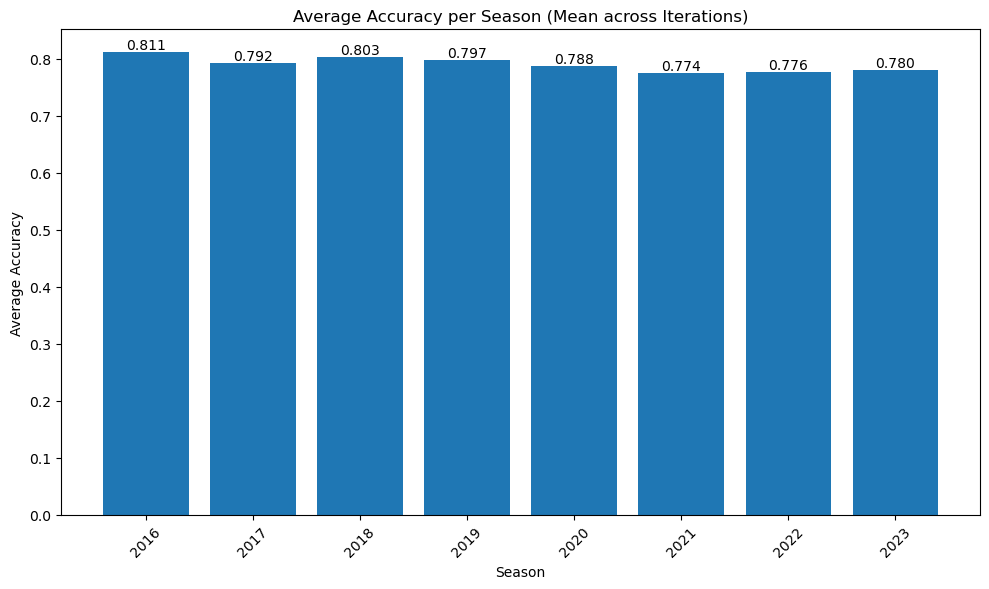

Overall Classification Report (in percentages):
0: {'precision': 79.25, 'recall': 78.81, 'f1-score': 79.03, 'support': 9795}

1: {'precision': 78.85, 'recall': 79.53, 'f1-score': 79.19, 'support': 9795}

2: {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 30}

accuracy: 79.05

macro avg: {'precision': 52.7, 'recall': 52.78, 'f1-score': 52.74, 'support': 19620}

weighted avg: {'precision': 78.93, 'recall': 79.05, 'f1-score': 78.99, 'support': 19620}



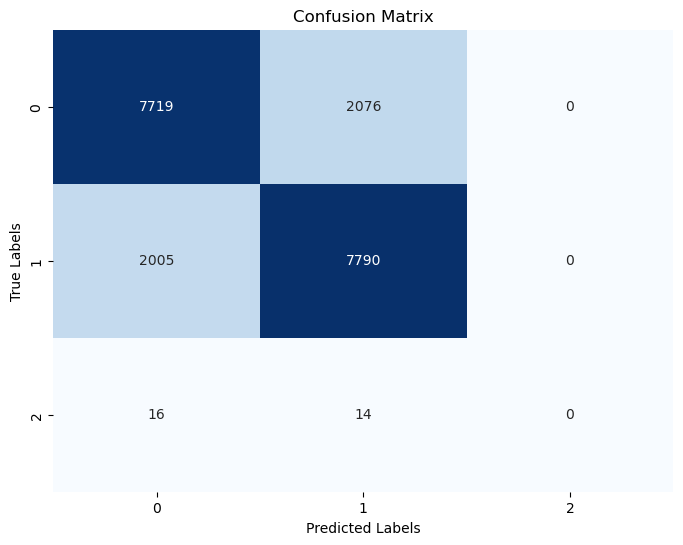

['ridge_classifier_model.h5']

In [9]:
## Machine Learning
removed_columns = ["season", "date", "won", "target", "team", "team_opp"]
removed_columns = list(engineered_Data.columns[engineered_Data.dtypes == "object"]) + removed_columns
selected_columns = engineered_Data.columns[~engineered_Data.columns.isin(removed_columns)]
selected_columns = selected_columns[selected_columns != "date_next"]  #Removing "date_next" from the list
# print(selected_columns)

## Data Normalization
scaler = MinMaxScaler()
engineered_Data[selected_columns] = scaler.fit_transform(engineered_Data[selected_columns])
# fullDF_nextGameInfo

# Create a Ridge classifier
ridge_classifier = RidgeClassifier()

# Define the TimeSeriesSplit for cross-validation
split = TimeSeriesSplit(n_splits=3)

# Initialize the SequentialFeatureSelector with the RR classifier
sfs = SequentialFeatureSelector(ridge_classifier,  # Use RR as the model
                                n_features_to_select=40,
                                direction="forward",
                                cv=split,
                                n_jobs=1
                                )

# Step 3: Create an empty dictionary to store accuracy results for each year
accuracy_by_year = {}

# Step 4: Create dictionaries to store sum and count of accuracy values for each year
sum_accuracy_by_year = {}
count_accuracy_by_year = {}

def backtest_with_iterative_improvement(data, model, predictors, start=2, step=1, iterations=20):
    all_predictions = []
    seasons = sorted(data["season"].unique())
    
    for iteration in range(iterations):
        print(f"Iteration {iteration + 1}")
        
        if isinstance(model, RidgeClassifier):  # Check if the model is RidgeClassifier
            model.set_params(alpha=0.1 + iteration * 0.1)  # Adapt the hyperparameter 'alpha'
        
        # Initialize the accuracy dictionaries for the current iteration
        accuracy_by_year[iteration + 1] = {}
        sum_accuracy_by_year[iteration + 1] = {}
        count_accuracy_by_year[iteration + 1] = {}
        
        for i in range(start, len(seasons), step):
            season = seasons[i]
            train = data[data["season"] < season]
            test = data[data["season"] == season]

            model.fit(train[predictors], train["target"])
            preds = model.predict(test[predictors])
            preds = pd.Series(preds, index=test.index)
            combined = pd.concat([test["target"], preds], axis=1)
            combined.columns = ["actual", "prediction"]
            all_predictions.append(combined)
            
            # Calculate accuracy for the current year
            accuracy = accuracy_score(combined["actual"], combined["prediction"])
            accuracy_by_year[iteration + 1][season] = accuracy
            
            # Update sum and count of accuracy values for the current year
            if season in sum_accuracy_by_year[iteration + 1]:
                sum_accuracy_by_year[iteration + 1][season] += accuracy
                count_accuracy_by_year[iteration + 1][season] += 1
            else:
                sum_accuracy_by_year[iteration + 1][season] = accuracy
                count_accuracy_by_year[iteration + 1][season] = 1
        
        predictions = pd.concat(all_predictions)
#         predictions = predictions[predictions['actual'] != 2]

        all_predictions = []
        
        # Continue with other steps for each iteration

    return predictions

start = time.time()
sfs.fit(engineered_Data[selected_columns], engineered_Data["target"])
predictors = list(selected_columns[sfs.get_support()])
print(predictors)
end = time.time()
print(f'{(end - start)/60} mins')

# Call the backtest_with_iterative_improvement function with the accuracy_by_year dictionary
predictions = backtest_with_iterative_improvement(engineered_Data, ridge_classifier, predictors)

# List of specific indices you want to see outcomes for
specific_indices = [ 7662,  7670,  7673,  7674,  7677,  7678,  7680,  7682,  7685,
             7687,  9546, 10313, 10316, 10348, 10350, 10357, 10358, 11829,
            11831, 11860, 17531, 17557, 19897, 19899, 20721, 20727, 21522,
            22384, 23111, 23774]

# Filter predictions for specific indices
specific_outcomes = predictions[predictions.index.isin(specific_indices)]

# Display the outcomes for the specific indices
print(specific_outcomes)

# Calculate the average accuracy for each year across all iterations
average_accuracy_by_year = {}
for iteration, accuracy_dict in accuracy_by_year.items():
    average_accuracy_by_year[iteration] = {}
    for year, accuracy in accuracy_dict.items():
        average_accuracy_by_year[iteration][year] = sum_accuracy_by_year[iteration][year] / count_accuracy_by_year[iteration][year]

# Extract the years and average accuracies for each iteration
years = list(average_accuracy_by_year[1].keys())
average_accuracies_per_iteration = [average_accuracy_by_year[iteration][year] for iteration in average_accuracy_by_year for year in average_accuracy_by_year[iteration]]

# Reshape the average accuracies to have 10 rows (one row per iteration)
average_accuracies_per_iteration = np.array(average_accuracies_per_iteration).reshape(20, -1)

# Calculate the mean of average accuracies across all iterations for each year
mean_average_accuracies = np.mean(average_accuracies_per_iteration, axis=0)

# Create a bar plot with the mean average accuracy values
plt.figure(figsize=(10, 6))
bars = plt.bar(years, mean_average_accuracies)
plt.xlabel("Season")
plt.ylabel("Average Accuracy")
plt.title("Average Accuracy per Season (Mean across Iterations)")
plt.xticks(rotation=45)

# Add text annotations with mean average accuracy values on each bar
for bar, accuracy in zip(bars, mean_average_accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, f"{accuracy:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Calculate the overall classification report
# Assuming you have predictions dictionary with "actual" and "prediction" keys
y_true = predictions["actual"]
y_pred = predictions["prediction"]
overall_classification_report = classification_report(y_true, y_pred, output_dict=True)

# Convert values to percentages and round to 2 decimal places
for class_name, metrics in overall_classification_report.items():
    if class_name not in ["accuracy", "macro avg", "weighted avg"]:
        precision = round(metrics['precision'] * 100, 2)
        recall = round(metrics['recall'] * 100, 2)
        f1_score = round(metrics['f1-score'] * 100, 2)
        support = metrics['support']
        overall_classification_report[class_name] = {
            'precision': precision,
            'recall': recall,
            'f1-score': f1_score,
            'support': support
        }

# Convert macro avg and weighted avg to percentages and round to 2 decimal places
macro_avg = overall_classification_report['macro avg']
macro_avg['precision'] = round(macro_avg['precision'] * 100, 2)
macro_avg['recall'] = round(macro_avg['recall'] * 100, 2)
macro_avg['f1-score'] = round(macro_avg['f1-score'] * 100, 2)

weighted_avg = overall_classification_report['weighted avg']
weighted_avg['precision'] = round(weighted_avg['precision'] * 100, 2)
weighted_avg['recall'] = round(weighted_avg['recall'] * 100, 2)
weighted_avg['f1-score'] = round(weighted_avg['f1-score'] * 100, 2)

# Convert accuracy to percentage and round to 2 decimal places
overall_classification_report['accuracy'] = round(overall_classification_report['accuracy'] * 100, 2)

# Print the modified classification report
print("Overall Classification Report (in percentages):")
for class_name, metrics in overall_classification_report.items():
    print(f"{class_name}: {metrics}")
    print()


# Calculate the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# # Calculate the overall ROC curve and AUC
# fpr, tpr, _ = roc_curve(y_true, y_pred)
# roc_auc = auc(fpr, tpr)
# print(f"Overall ROC AUC: {roc_auc}")

# # Plot the overall ROC curve
# plt.figure(figsize=(8, 6))
# plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic')
# plt.legend(loc="lower right")
# plt.show()


# Save the trained Ridge classifier model to an h5 file using joblib
model_filename = "ridge_classifier_model.h5"
joblib.dump(ridge_classifier, model_filename)

In [ ]:
# # Create a DataFrame with actual and predicted outcomes
# outcome_table = predictions[['actual', 'prediction']]

# # Display the outcome table
# print(outcome_table)

In [ ]:
# # Convert the Int64Index to a Python list
# indices_list = outcome_table.index.tolist()

# # Print all indices without collapsing
# print(indices_list)

In [31]:
# # Convert the Int64Index of the outcome_table DataFrame to a Python list
# outcome_indices_list = outcome_table.index.tolist()

# # Print all indices without collapsing
# for index in outcome_indices_list:
#     print(index)

In [ ]:
# # List of specific indices you want to see outcomes for
# specific_indices = [ 7662,  7670,  7673,  7674,  7677,  7678,  7680,  7682,  7685,
#              7687,  9546, 10313, 10316, 10348, 10350, 10357, 10358, 11829,
#             11831, 11860, 17531, 17557, 19897, 19899, 20721, 20727, 21522,
#             22384, 23111, 23774]

# # Select rows based on specific indices
# specific_outcomes = outcome_table.loc[specific_indices]

# # Display the outcomes for the specific indices
# print(specific_outcomes)

In [13]:
next_games = engineered_Data[engineered_Data["target"] == 2][['date_next', 'team_x', 'team_opp_next_x']]

In [14]:
result = pd.concat([next_games, specific_outcomes], axis=1)
result

,date_next,team_x,team_opp_next_x,actual,prediction
7662,26/10/2023,SAS,DAL,2,1
7670,26/10/2023,ORL,HOU,2,0
7673,26/10/2023,IND,WAS,2,1
7674,26/10/2023,HOU,ORL,2,1
7677,26/10/2023,POR,LAC,2,0
7678,26/10/2023,UTA,SAC,2,1
7680,26/10/2023,WAS,IND,2,0
7682,26/10/2023,CHA,ATL,2,0
7685,26/10/2023,DAL,SAS,2,0
7687,26/10/2023,DET,MIA,2,0


## Load the saved model:

In [ ]:
# Load the saved Ridge classifier model
loaded_model = joblib.load("ridge_classifier_model.h5")

# Make predictions on the new data
predictions = loaded_model.predict(new_data[selected_columns])

# 'predictions' now contains the predicted values for your new data

## Feature Importance

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
                        Feature  Importance
25  head_to_head_win_ratio_next    0.511973
23                    home_next    0.137352
24          elo_rating_opp_next    0.050428
10              cumulative_wins    0.048240
21          cumulative_wins_4_x    0.034344
4                  PER_Combined    0.029042
26        avg_points_scored_4_y    0.022474
39                   season_4_y    0.018822
33              win_percent_4_y    0.017095
30       point_differential_4_y    0.015609


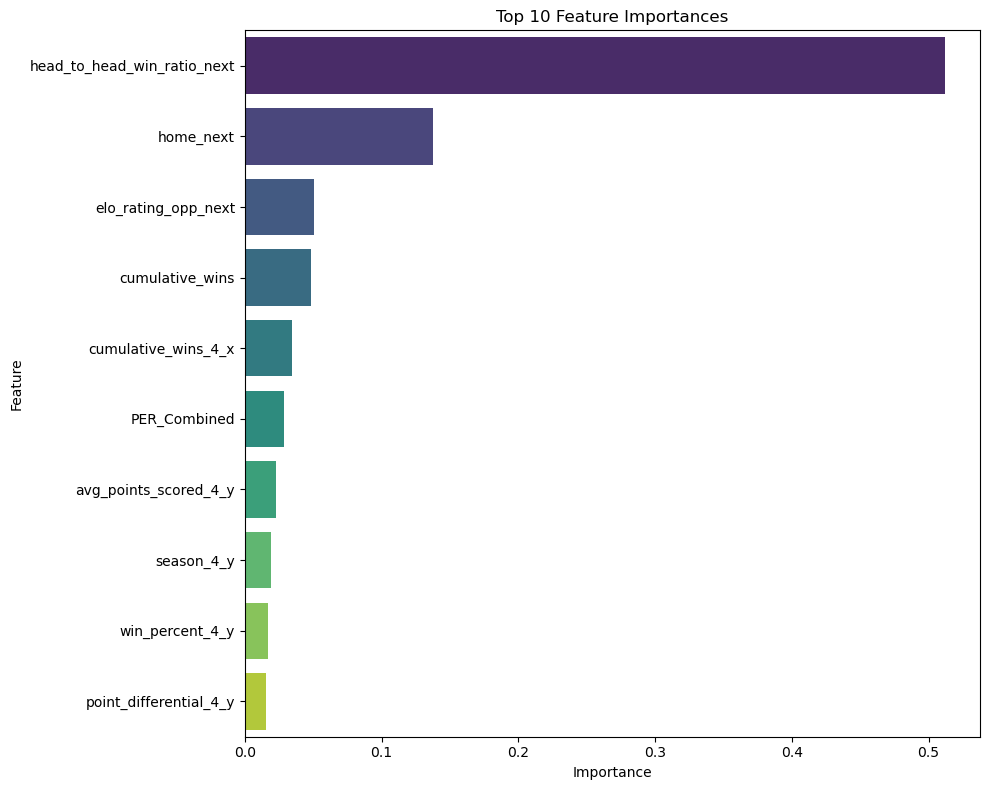

0.1346537709236145 mins


In [9]:
start = time.time()

# Call the backtest_with_iterative_improvement function with the accuracy_by_year dictionary
predictions = backtest_with_iterative_improvement(engineered_Data, ridge_classifier, predictors)

# Create an explainer using SHAP
explainer = shap.Explainer(ridge_classifier, engineered_Data[predictors])

# Calculate SHAP values for the entire dataset
shap_values = explainer(engineered_Data[predictors])

# Get the mean absolute SHAP values for each feature
mean_abs_shap_values = pd.DataFrame(abs(shap_values.values)).mean(axis=0)

# Create a DataFrame to store feature importance scores
feature_importance = pd.DataFrame({"Feature": predictors, "Importance": mean_abs_shap_values})

# Sort the DataFrame by feature importances in descending order
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Print the top 10 features and their importance scores
top_10_features = feature_importance.head(10)
print(top_10_features)

# Create a horizontal bar plot to visualize the top 10 feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x="Importance", y="Feature", data=top_10_features, palette="viridis")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

end = time.time()
print(f'{(end - start)/60} mins')

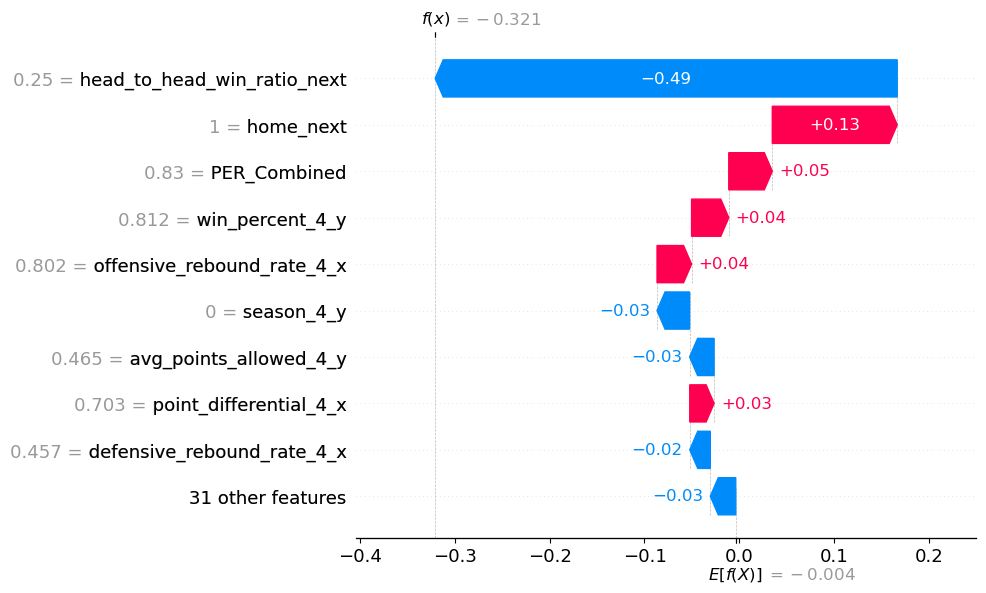

In [10]:
explainer = shap.Explainer(ridge_classifier, engineered_Data[predictors])
shap_values = explainer(engineered_Data[predictors])
instance_index = 0  # Change this to the index of the instance you want to explain
shap.plots.waterfall(shap_values[instance_index], max_display=10)  # Change max_display as needed